In [16]:
import os 
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
import importlib, helper
importlib.reload(helper)
from helper import MODEL_PROPERTIES, transform

In [19]:
%matplotlib inline

# plot all game, across all lang

A plot of 3x3 subplots, showing the distribution of Main Score across 2 categorical variables:  
* commercial (Y/N): will be plotted on x-axis 
* reasoning (Y/N): will be plotted as different color of dots

Each dot represent the Main Score of a success episode; aborted episodes are not reflected. 

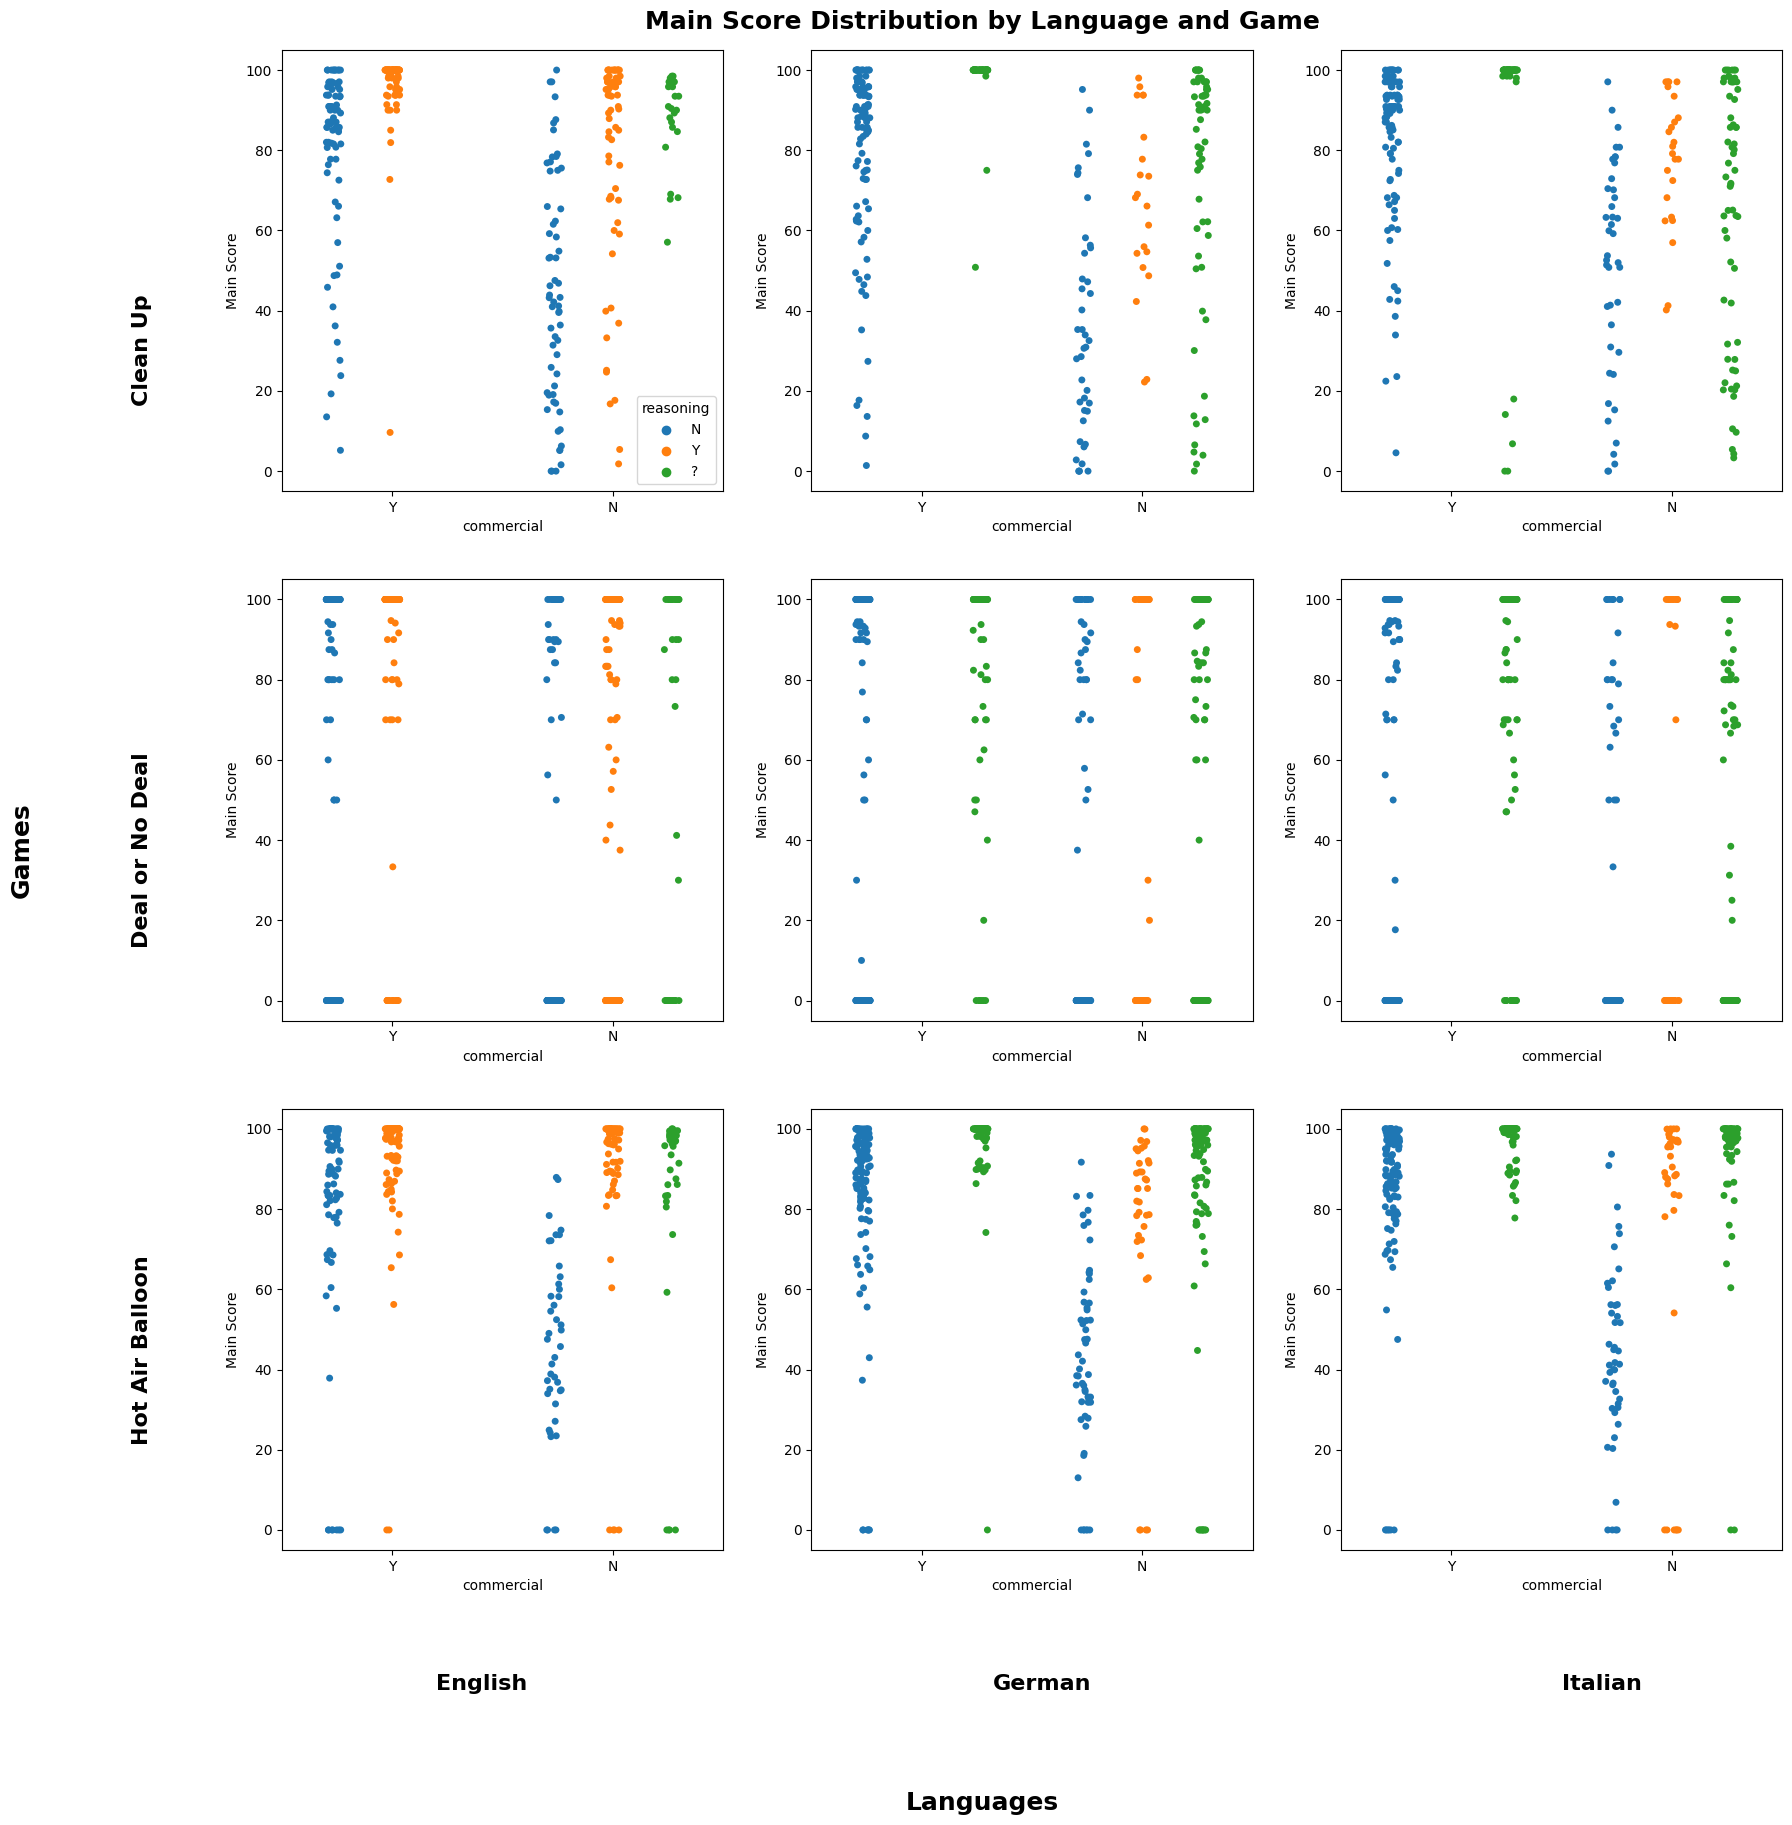

In [27]:
LANGS = {
    "en": "English",
    "de": "German",
    "it": "Italian"
}
GAMES = {
    "clean_up": "Clean Up",
    "dond": "Deal or No Deal",
    "hot_air_balloon": "Hot Air Balloon"
}

fig, axes = plt.subplots(
    nrows=len(GAMES), ncols=len(LANGS),
    figsize=(20, 20)
)

all_main_scores = []

for col_idx, (lang, lang_name) in enumerate(LANGS.items()):
    df = pd.read_csv(f"../results_{lang}/raw.csv")
    df_pv = transform(df)

    all_main_scores.extend(df_pv["Main Score"].dropna())

    for row_idx, (game, game_name) in enumerate(GAMES.items()):
        df_focus = df_pv.query("game == @game")
        ax = axes[row_idx, col_idx]

        sns.stripplot(
            data=df_focus, x="commercial", y="Main Score", hue="reasoning",
            dodge=True, jitter=True, ax=ax, legend=(row_idx == 0 and col_idx == 0)
        )

# Titles & labels
fig.suptitle("Main Score Distribution by Language and Game", fontsize=18, fontweight="bold", y=0.92)
fig.text(0.5, 0.02, "Languages", ha="center", fontsize=18, fontweight="bold")
fig.text(0.02, 0.5, "Games", ha="center", va="center", rotation=90, fontsize=18, fontweight="bold")

# Column labels
for col_idx, lang_name in enumerate(LANGS.values()):
    fig.text(0.25 + col_idx * 0.28, 0.08, lang_name, ha="center", fontsize=16, fontweight="bold")

# Row labels
for row_idx, game_name in enumerate(GAMES.values()):
    fig.text(0.08, 0.75 - row_idx * 0.25, game_name, ha="center", va="center",
             rotation=90, fontsize=16, fontweight="bold")

# plt.tight_layout(rect=[0.15, 0.15, 0.95, 0.9])
plt.subplots_adjust(left=0.15, bottom=0.15, top=0.9, hspace=0.2)  
plt.savefig("main_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
